In [1]:
from importlib.machinery import SourceFileLoader
import glob
import pandas as pd
import pdb
import matplotlib.pyplot as plt
import numpy as np
import re
np.set_printoptions(precision=3, linewidth=150)
plt.style.use('seaborn')
plt.rc('figure',figsize=(20,12))
plt.rc('axes', labelsize=24)
plt.rc('xtick',labelsize=22)
plt.rc('ytick',labelsize=22)
plt.rc('legend', fontsize=24)
plt.rc('font', size=24)
plt.rc('lines',markersize=10)
# from GetAtomsObjects import BopFoxParser

np.set_printoptions(precision=2, formatter={'float_kind':'{:-6.2f}'.format}, linewidth=120)

#load the function to retrieve raw positions
from PoscarReader import get_raw_positions

import ase

import pickle
from itertools import product
from string import ascii_uppercase

In [2]:
def fix_the_positions(Positions: np.ndarray):
    new_positions = Positions.copy()
    new_positions = np.where(new_positions > 1, new_positions - 1, new_positions)
    new_positions = np.where(new_positions < 0  , new_positions+1, new_positions)
    return new_positions

The following will sort the sublattices in both initial and relaxed poscars/ 

In [20]:
run SublatticeSorter.py POSCAR.initial

> /home/storage/fortimtb/DatasetsML/Cr-Co-W/SublatticeSorter.py(70)get_list_poscars()
     68     pdb.set_trace()
     69 
---> 70     for thisfile in tqdm(files):
     71         SORTER = []
     72         POSCAR = pd.read_csv(thisfile, sep='\n', dtype='str', header=None)[0]



ipdb>  l


     65 
     66     SORTERS = {}
     67     SUBLATICETAGS = {}
     68     pdb.set_trace()
     69 
---> 70     for thisfile in tqdm(files):
     71         SORTER = []
     72         POSCAR = pd.read_csv(thisfile, sep='\n', dtype='str', header=None)[0]
     73         wheredirect = get_coord_type_line(POSCAR)
     74         natoms = get_number_of_atoms(POSCAR, wheredirect)
     75         for SITE in ascii_uppercase:



ipdb>  q


BdbQuit: 

In [15]:
!cat Co_pv/POSCAR-relaxed/R.FM/relax/xc=PBE-PAW.E=400.dk=0.020/POSCAR.relaxed-all

cat: 'Co_pv/POSCAR-relaxed/R.FM/relax/xc=PBE-PAW.E=400.dk=0.020/POSCAR.relaxed-all': No such file or directory


In [25]:
    run GetAtomsObjects.py

POSCAR-initial rescaled True **/POSCAR-initial


100%|█████████████████████████████████████████████████████████████████████████████████████████| 1687/1687 [00:36<00:00, 45.92it/s]


POSCAR-initial noscaled False **/POSCAR-initial


100%|█████████████████████████████████████████████████████████████████████████████████████████| 1687/1687 [00:38<00:00, 44.35it/s]


POSCAR-relaxed rescaled True **/POSCAR-relaxed


100%|█████████████████████████████████████████████████████████████████████████████████████████| 1687/1687 [00:46<00:00, 36.27it/s]


POSCAR-relaxed noscaled False **/POSCAR-relaxed


100%|█████████████████████████████████████████████████████████████████████████████████████████| 1687/1687 [00:37<00:00, 44.42it/s]


The atoms objects list created should be sorted and ordered already: 

In [4]:
Initial = pd.read_pickle('CrCoW-sorted-POSCAR-initial-noscaled-AtomsObjects.pkl').dropna()
Relaxed = pd.read_pickle('CrCoW-sorted-POSCAR-relaxed-noscaled-AtomsObjects.pkl').dropna()

In [5]:
Relaxed.file[0]

array(['Co_pv-W_sv/POSCAR-relaxed/C14-BBA.FM/relax/xc=PBE-PAW.E=400.dk=0.020/POSCAR.relaxed-all-sorted'], dtype=object)

In [8]:
Relaxed['raw_positions'] = Relaxed['file'].map(lambda s: get_raw_positions(s[0]))

In [9]:
Initial['raw_positions'] = Initial['file'].map(lambda s: get_raw_positions(s[0]))

In [10]:
Initial['raw_positions'] = Initial['raw_positions'].map(fix_the_positions)

In [11]:
Relaxed['raw_positions'][Relaxed.index.str.contains('chi-BABB')&Relaxed.index.str.contains('FM')]#[0].get_scaled_positions() #.map(fix_the_positions).iloc[-1].get_scaled_positions()

index
Co_pv4W_sv25.chi-BABB.FM     [[-0.0, 0.0, -0.0], [0.6382409302609874, 0.638...
Cr_pv4W_sv25.chi-BABB.FM     [[-0.0, 0.0, -0.0], [0.633928032165222, 0.6339...
Cr_pv4Co_pv25.chi-BABB.FM    [[-0.0, 0.0, -0.0], [0.6423018093099588, 0.642...
Name: raw_positions, dtype: object

In [13]:
inboth_index = Initial.index.intersection(Relaxed.index)

I still need to get equal indices in the lattice tags. and in the sorter

In [15]:
POSITIONS = Relaxed['atoms'].map(lambda a: a.get_scaled_positions())

# Sublattice Tags

The sublattice tags are calculated by the sublattice sorter script

In [24]:
SUBLATICETAGS

Co_pv/POSCAR-initial/R.FM/relax/xc=PBE-PAW.E=400.dk=0.020/POSCAR.initial                         [A, B, B, C, C, C, C, C, C, D, D, D, D, D, D, ...
Co_pv/POSCAR-initial/R/relax/xc=PBE-PAW.E=400.dk=0.020/POSCAR.initial                            [A, B, B, C, C, C, C, C, C, D, D, D, D, D, D, ...
Co_pv/POSCAR-initial/sigma.DDDDD/relax/xc=PBE-PAW.E=400.dk=0.020/POSCAR.initial                  [A, A, B, B, B, B, C, C, C, C, C, C, C, C, D, ...
Co_pv/POSCAR-initial/sigma.DDDDU/relax/xc=PBE-PAW.E=400.dk=0.020/POSCAR.initial                  [A, A, B, B, B, B, C, C, C, C, C, C, C, C, D, ...
Co_pv/POSCAR-initial/sigma.DDDUD/relax/xc=PBE-PAW.E=400.dk=0.020/POSCAR.initial                  [A, A, B, B, B, B, C, C, C, C, C, C, C, C, D, ...
                                                                                                                       ...                        
Cr_pv-Co_pv-W_sv/POSCAR-initial/sigma-CCBCA/relax/xc=PBE-PAW.E=400.dk=0.020/POSCAR.initial       [A, A, A, A, A, A, A,

In [27]:
SUBLATICETAGS[Initial['file'].map(lambda v: v[0].replace('-sorted',''))]

Co_pv-W_sv/POSCAR-initial/C14-BBA.FM/relax/xc=PBE-PAW.E=400.dk=0.020/POSCAR.initial                           [A, A, A, A, B, B, C, C, C, C, C, C]
Co_pv-W_sv/POSCAR-initial/C14-BBA/relax/xc=PBE-PAW.E=400.dk=0.020/POSCAR.initial                              [A, A, A, A, B, B, C, C, C, C, C, C]
Cr_pv-W_sv/POSCAR-initial/D0_19-A3B.FM/relax/xc=PBE-PAW.E=400.dk=0.020/POSCAR.initial                                     [A, A, A, A, A, A, B, B]
Cr_pv-W_sv/POSCAR-initial/D0_19-A3B/relax/xc=PBE-PAW.E=400.dk=0.020/POSCAR.initial                                        [A, A, A, A, A, A, B, B]
Cr_pv-Co_pv-W_sv/POSCAR-initial/sigma-CBAAC.FM/relax/xc=PBE-PAW.E=400.dk=0.020/POSCAR.initial    [A, A, A, A, A, A, A, A, A, A, A, A, A, A, A, ...
                                                                                                                       ...                        
Cr_pv-Co_pv-W_sv/POSCAR-initial/sigma-BAACA.FM/relax/xc=PBE-PAW.E=400.dk=0.020/POSCAR.initial    [A, A, A, A, A, A, A,

In [28]:
def order_sublattices_asin(df_with_tags, df_ref_atoms):
    """
    this function orders the sublattice tags as in the reference dataframe. 
    for the ordering, the exact coincidence of the file is taken.
    """
    return df_with_tags.loc[
        df_ref_atoms['file'].apply(lambda f: f[0].replace('-sorted','')).values
    ]

In [30]:
OSUBLATICES = order_sublattices_asin(SUBLATICETAGS, Initial) # SUBLATICETAGS.loc[Initial['file'].apply(lambda f: f[0].replace('-sorted','')).values]
OSUBLATICES.index = Initial.index

In [31]:
def get_first(thearray):
    return np.array([ x[0] if len(x)>0 else 'A' for x in thearray ])

# Volumes after relax

In [32]:
vol_initi = Initial['atoms'].apply(lambda atom: atom.cell.volume)
vol_relax = Relaxed['atoms'].apply(lambda atom: atom.cell.volume)

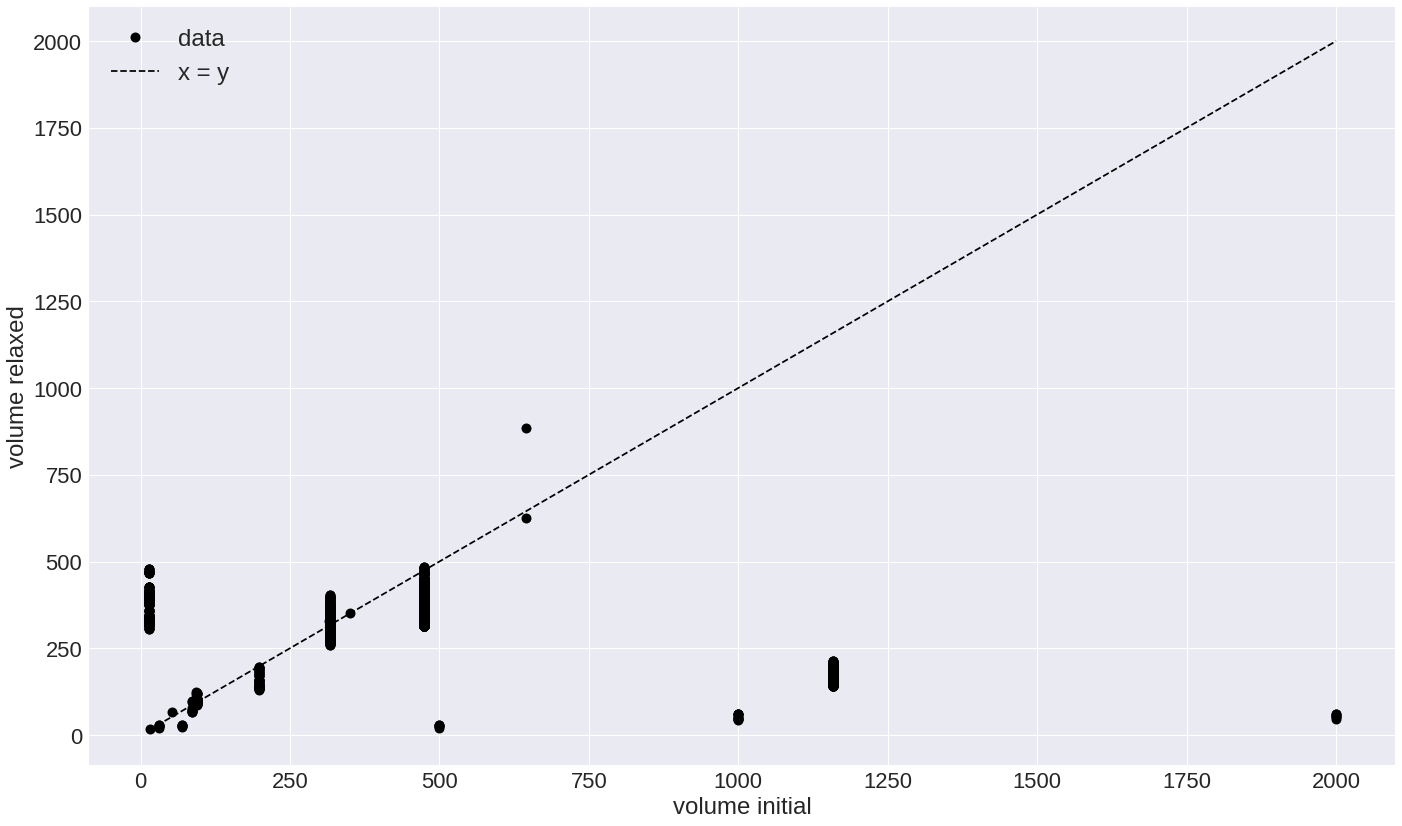

In [33]:
#plt.plot(vol_proto.loc[inboth_index], vol_proto.loc[inboth_index],'--k')
plt.plot(vol_initi.loc[inboth_index], vol_relax.loc[inboth_index],'ok', label='data')
xy = np.linspace(vol_initi.min(), vol_initi.max(),3)
plt.plot(xy,xy,'--k',label='x = y')
plt.legend()
plt.xlabel('volume initial')
plt.ylabel('volume relaxed')
plt.gcf().tight_layout()

# Relaxations by sublattices: Binaries

In [34]:
phase = 'C14'

In [37]:
def average_by_sublatice(phase,_OSUBLATICES=OSUBLATICES[inboth_index]):
    selection = (_OSUBLATICES.index.str.contains(phase) & _OSUBLATICES.index.str.contains('Co')  & _OSUBLATICES.index.str.contains('Cr')  & ~_OSUBLATICES.index.str.contains('W')) |\
                (_OSUBLATICES.index.str.contains(phase) & _OSUBLATICES.index.str.contains('Co')  & ~_OSUBLATICES.index.str.contains('Cr')  & _OSUBLATICES.index.str.contains('W')) |\
                (_OSUBLATICES.index.str.contains(phase) & ~_OSUBLATICES.index.str.contains('Co')  & ~_OSUBLATICES.index.str.contains('Cr')  & _OSUBLATICES.index.str.contains('W'))

    selected_sublatices = _OSUBLATICES[selection]
    selected_positions = Relaxed[selection]['atoms'].map(lambda a: a.get_scaled_positions())
    IS = []
    Positions={}
    for TAG in ascii_uppercase:
        IS = selected_sublatices.map(lambda tags: TAG == tags)
        if IS[0].sum()>0:
            Positions[TAG] = pd.Series([ positions[_is_]  for positions, _is_ in zip (selected_positions.values, IS.values) ])
    return Positions

In [38]:
Positions_C14 = average_by_sublatice('C14')

In [39]:
Positions_C14['A'].values.std()

array([[  0.00,   0.00,   0.01],
       [  0.00,   0.00,   0.01],
       [  0.00,   0.00,   0.01],
       [  0.00,   0.00,   0.01]])

In [40]:
Positions_C14['B'].values.std()

array([[  0.00,   0.00,   0.00],
       [  0.00,   0.00,   0.00]])

In [41]:
Positions_C14['C'].values.std()

array([[  0.00,   0.00,   0.00],
       [  0.00,   0.00,   0.00],
       [  0.00,   0.00,   0.00],
       [  0.00,   0.00,   0.00],
       [  0.00,   0.00,   0.00],
       [  0.00,   0.00,   0.00]])

In [42]:
Positions_sigma = average_by_sublatice('sigma')

In [44]:
Positions_sigma['E'].values.std()

array([[  0.00,   0.00,   0.00],
       [  0.00,   0.00,   0.00],
       [  0.00,   0.00,   0.00],
       [  0.00,   0.00,   0.00],
       [  0.00,   0.00,   0.00],
       [  0.00,   0.00,   0.00],
       [  0.00,   0.00,   0.00],
       [  0.00,   0.00,   0.00]])

# Proof tat atoms objects are sorted

In [ ]:
Relaxed.columns

for all the compounds with the same structure, all the positions should have the same indexes in all occurrences

In [ ]:
inboth_index

In [45]:
Relaxed.columns

Index(['atoms', 'file', 'raw_positions'], dtype='object')

In [46]:
selection_rlx = \
    Relaxed.index.str.contains('FM') & \
    Relaxed.index.str.contains('C36') & \
    Relaxed.index.str.contains('^Co_pv')

In [47]:
selection_rlx.any()

True

There are still problems with some phases, a second sorting criteria might be needed

In [48]:
#Relaxed.drop(index='Fe_pv4Mo_sv25.chi-BABB.FM', inplace=True)

In [49]:
for index, sorter in Relaxed[selection_rlx].iterrows():
    print ('{:>10s}\n'.format(index), '{:10s}'.format('rela x   :'), Relaxed['raw_positions'][index][:20,1].ravel())#.get_positions()[:15,0])

Co_pv10W_sv14.C36-ABBBA.FM
 rela x   : [  0.00   0.00   0.00   0.00   0.67   0.33   0.33   0.67   0.67   0.33   0.33   0.67   0.00   0.50   0.50   0.00   0.50
   0.50   0.31   0.85]
Co_pv10W_sv14.C36-BBAAB.FM
 rela x   : [ -0.00  -0.00  -0.00  -0.00   0.67   0.33   0.33   0.67   0.67   0.33   0.33   0.67  -0.00   0.50   0.50  -0.00   0.50
   0.50   0.33   0.84]
Co_pv10W_sv14.C36-BBABA.FM
 rela x   : [  0.00   0.00   0.00   0.00   0.67   0.33   0.33   0.67   0.67   0.33   0.33   0.67   0.00   0.50   0.50   0.00   0.50
   0.50   0.32   0.84]
Co_pv8W_sv16.C36-BAABB.FM
 rela x   : [  0.00   0.00   0.00   0.00   0.67   0.33   0.33   0.67   0.67   0.33   0.33   0.67   0.00   0.50   0.50   0.00   0.50
   0.50   0.33   0.84]
Co_pv6W_sv18.C36-BBBAB.FM
 rela x   : [  0.00   0.00   0.00   0.00   0.67   0.33   0.33   0.67   0.67   0.33   0.33   0.67   0.00   0.50   0.50   0.00   0.50
   0.50   0.33   0.84]
Co_pv4W_sv20.C36-BABBB.FM
 rela x   : [  0.00   0.00   0.00   0.00   0.67   0.33   0.33   0.

In [50]:
selection_rlx =\
    Relaxed.index.str.contains('FM') & \
    Relaxed.index.str.contains('A15') &\
    Relaxed.index.str.contains('^Co_pv')

In [51]:
for index, sorter in Relaxed[selection_rlx].iterrows():
    print ('{:>10s}\n'.format(index), '{:10s}'.format('rela x   :'), Relaxed['raw_positions'][index][:20,1].ravel())#.get_positions()[:15,0])

Co_pv2W_sv6.A15-BA.FM
 rela x   : [  0.00  -0.00   0.25   0.75   0.50   0.50   0.00   0.50]
Co_pv6W_sv2.A15-AB.FM
 rela x   : [ -0.00  -0.00   0.25   0.75   0.50   0.50  -0.00   0.50]


# so lets sort them all 

This is not necesary any more, but the following code would have made the work if starting from the existing atoms objects. reading the poscars would still be necesary as sublattice info is saved there.

# The parsed data:

this is necesary in my setup as it makes it easy to filter by composition. The composition of each strucure is read from briefsumaries but can also be parsed from file names. To make it work , one needs my version of Bopfox featurizers. The `parsed` variable is created in `GetAtomsObjects.py` and saved as a pickle that we need to pick

In [62]:
from BopFoxFeaturizer.brief_summary_parser import irregular_file_parser, StructSummaryParser
from BopFoxFeaturizer.parsers import BopFoxParser

In [63]:
with open('parsed_briefsummaries.pkl','rb') as f:
    Parsed = pickle.load(f)

ModuleNotFoundError: No module named 'BopFoxParser'

# Binaries 

In [57]:
indexes = Parsed.data.index

NameError: name 'Parsed' is not defined

In [58]:
BinariesCoW = Parsed.data[ (Parsed.data['nelem']==2).values & Parsed.data.index.str.contains('W_sv')&  Parsed.data.index.str.contains('Co_pv') ]

NameError: name 'Parsed' is not defined

In [ ]:
BinariesCrW = Parsed.data[ (Parsed.data['nelem']==2).values & Parsed.data.index.str.contains('Cr')&  Parsed.data.index.str.contains('W') ]

In [53]:
BinariesCrCo = Parsed.data[ (Parsed.data['nelem']==2).values & Parsed.data.index.str.contains('Cr')&  Parsed.data.index.str.contains('Co') ]

NameError: name 'Parsed' is not defined

In [54]:
BinariesCoW

NameError: name 'BinariesCoW' is not defined

In [55]:
XW_binariesCoW = BinariesCoW['num_atom_B']/BinariesCoW[['num_atom_A','num_atom_B']].sum(axis=1)

NameError: name 'BinariesCoW' is not defined

In [ ]:
XW_binariesCoW

# Exploration of binaries

In [ ]:
binaries = [('Cr','Co','^W'), ('Co','W','^Cr'), ('Cr','W','^Co')]

In [ ]:
phases = Parsed.StrucNames.unique()

In [ ]:
phases = ['C14','sigma', 'chi', 'A15']
mags = ['FM']#,'NM']

In [ ]:
#TheBinaries = Parsed.data[Parsed.data['nelem'] == 2 ]
TheRelaxedData = Parsed.data.loc[Relaxed.index]
TheBinariesRelaxed = TheRelaxedData[TheRelaxedData['nelem']==2]

In [ ]:
phases

In [ ]:
def dothemeans(_XB, _TheBinaryRelaxedPositions):
    xs = np.sort(_XB.unique())
    stds = []
    means = []
    for x in xs: 
        selection = np.abs(_XB - x) < 1e-3
        if any(selection):
            thispositions = _TheBinaryRelaxedPositions[selection]['raw_positions']
            stds.append(thispositions.values.std())
            means.append(thispositions.values.mean())
    return xs, means, stds

stds = {}
means = {}
xs  = {}
for thisbin, thisphase, thismag in product(binaries, phases, mags):
    # TheBinariesRelaxed.index.str.contains(thisbin[-1]) &
    TheBinaryRelaxed = TheBinariesRelaxed[ 
         TheBinariesRelaxed['atom_B'].str.contains(thisbin[1]) &
        TheBinariesRelaxed.index.str.contains(thisphase) & TheBinariesRelaxed.index.str.contains(thismag)
    ]
    TheBinaryRelaxedPositions = Relaxed.loc[TheBinaryRelaxed.index]
    XB = TheBinaryRelaxed['num_atom_A']/TheBinaryRelaxed[['num_atom_A','num_atom_B']].sum(axis=1)
    thekey = ''.join(thisbin[:-1])+'-'+thisphase+'.'+thismag
    xs[thekey], means[thekey], stds[thekey] = dothemeans(XB, TheBinaryRelaxedPositions)
#    thex, themeans, thestds = makepossds(XB, 'A15', 'FM')
    #TheFMBinaryRelaxedPositions = TheBinariesRelaxed.loc[ TheBinariesRelaxed.index.str.contains(thisbin[-1]) & TheBinariesRelaxed.index.str.contains('FM') ] 
    #XB = TheBinaryRelaxedPositions['num_atom_A']

In [ ]:
for key in xs.keys():
    stdevol = np.array([std.max(axis=0) for std in stds[key]])
    fig = plt.figure()
    plt.suptitle(key)
    plt.plot(xs[key],stdevol)
    plt.xlabel('$X_B$')
    plt.ylabel('max standard deviation')
    plt.legend(['x','y','z'])
    fig.tight_layout()

In [ ]:
means

In [ ]:
stds

In [ ]:
phases

In [ ]:
with np.printoptions(precision=2, formatter={'float_kind':'{:-6.2f}'.format}, linewidth=300):
    print('x: -------------------')
    [print(xyz[:,0]) for xyz in means['CoW']]
    print('y: -------------------')
    [print(xyz[:,1]) for xyz in means['CoW']]
    print('z: -------------------')
    [print(xyz[:,1]) for xyz in means['CoW']]

In [ ]:
Parsed.StrucNames.hist()